<h1 style="display:flex; align-items:center; line-height:1; margin:0;">
  <img src="rwcircle.png" style="height:36px; width:36px; border-radius:50%; flex-shrink:0;">
  <span style="padding-top:2px; margin-left:10px;"><b>Optional stopping eclipse simulations</b>: the case of GJ 3929 b</span>
</h1>

***
**Author**: Nestor Espinoza (nespinoza@stsci.edu) | **Date of last change**: March 30th, 2026

## Summary
In this notebook, we perform some simulations to showcase the "dangers" of optional stopping when it comes to measuring eclipse depths in terms of biases on their estimates if we base stopping decisions on detectability metrics. Intuitively, the idea is that if we stop observations because we detect a large eclipse depth, random samples that lead to such large eclipse depths will preferentially lead to us to stop observations, which has in turn the potential to bias eclipse depths to higher values.

## Imports
 We will need three simple imports for this notebook:
- *numpy* to handle array functions,
- *matplotlib.pyplot* for plotting data,
- *seaborn* for giving publication-quality style to plots 

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('ticks')

import matplotlib as mpl 

We will be doing some random number generation, so we set the seed:

In [2]:
np.random.seed(127)

And we define some plotting setups:

In [3]:
# And also Arial fonts :-):
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# No top and right edges:
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

***

## 1. General simulation setup

We begin this notebook by defining a function that makes a noisy box-shaped eclipse of `Nin` in-eclipse points and `Nout` points out-of-eclipse:

In [4]:
def make_eclipse(Nin, Nout, depth, noise):
    """
    Nin:     number of datapoints in-eclipse.
    Nout:    number of datapoints out-of-eclipse.
    depth:   eclipse depths in ppm.
    noise:   light curve noise in ppm.
    """

    Ntotal = Nin + Nout                                          # Total number of datapoints
    
    model = np.ones( Ntotal ) + (depth * 1e-6)                   # Set all value to out-of-eclipse values
    model[int(Nout/2):-int(Nout/2)] = 1.                         # Set in-eclipse points to stellar flux
    
    return model, model + np.random.normal(0, noise, Ntotal) * 1e-6     # Return noisy light curve

Let's check if it works:

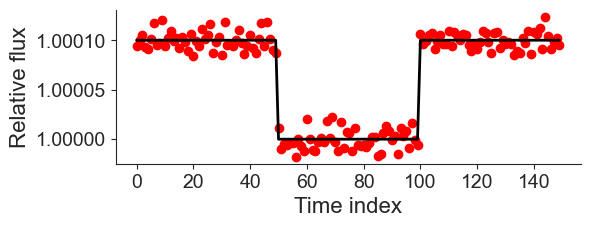

In [5]:
Nin = 50
Nout = 100
depth = 100
noise = 10
model, data = make_eclipse(Nin, Nout, depth, noise)

plt.figure( figsize=(6, 2) )

plt.plot( data , 'ro')
plt.plot( model , '-', lw = 2, color = 'black')

plt.ticklabel_format(useOffset=False)

plt.xlabel('Time index', fontsize = 16)
plt.ylabel('Relative flux', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.show()

Neat! Now let's write a function that gives us back an estimated eclipse depth, $\hat{\delta}$. Analytically, this is easy to compute in this case --- it's simply the average out-of-eclipse minus the average in-eclipse. Let's write a function that gets us this that is consistent with the eclipse-generating function above:

In [6]:
def get_depth(data, Nin, Nout):

    # Get data in and out of eclipse:
    data_in_eclipse = data[int(Nout/2):-int(Nout/2)]
    data_out_of_eclipse = np.append( data[:int(Nout/2)-1], data[-int(Nout/2):] )

    # Apply mean and variance rules:
    depth = ( np.sum(data_out_of_eclipse) / len(data_out_of_eclipse) ) - \
            ( np.sum(data_in_eclipse) / len(data_in_eclipse) )

    error = np.sqrt( 
            np.var(data_out_of_eclipse) * ( 1. / len(data_out_of_eclipse)) + \
            np.var(data_in_eclipse) * ( 1. / len(data_in_eclipse) ) \
            )

    return depth * 1e6, error * 1e6

Let's test these give back what we put in via a Monte-Carlo simulation:

In [7]:
nsim = 5000
depths = np.zeros(nsim)
errors = np.zeros(nsim)

for i in range(nsim):

    _, data = make_eclipse(Nin, Nout, depth, noise)
    depths[i], errors[i] = get_depth(data, Nin, Nout)

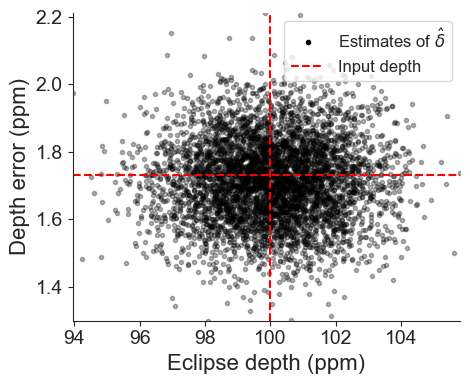

In [8]:
plt.figure( figsize=(5, 4) )

expected_error = noise * np.sqrt( (1. / Nout) + (1. / Nin) )

plt.plot(depths, errors, '.', color = 'black', alpha = 0.3)
plt.plot([0,0],[0,0], '.', color = 'black', label = r'Estimates of $\hat{\delta}$')
plt.plot([depth, depth], [np.min(errors), np.max(errors)], 'r--', label = 'Input depth')
plt.plot([np.min(depths), np.max(depths)], [expected_error, expected_error], 'r--')
plt.xlim(np.min(depths), np.max(depths))
plt.ylim(np.min(errors), np.max(errors))

plt.xlabel('Eclipse depth (ppm)', fontsize = 16)
plt.ylabel('Depth error (ppm)', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(fontsize = 12, loc = 'upper right')
plt.show()

It works! Let's now go to the simulations.

## 2. Simulations
### 2.1 The case of GJ 3929 b

Let's first simulate the case for the parameters of GJ 3929 b. To this end, first let's load the CIT data:

In [9]:
planet_names, times_per_int, precisions_per_int, eclipse_durations, observing_times, \
eclipse_errors, fpfs_rock, fpfs_co2 = np.genfromtxt(
                                          'calculations.csv',
                                          skip_header = 1,
                                          usecols = (0, 1, 4, 5, 6, 7, 9, 10),
                                          delimiter=',',
                                          dtype=None,
                                          encoding=None,
                                          unpack=True,
                                          autostrip=True,
                                      )

# Save data in a dictionary:
CIT_calculations = {}
for i in range( len(planet_names) ):

    CIT_calculations[planet_names[i]] = {}
    CIT_calculations[planet_names[i]]['time per integration'] = times_per_int[i]
    CIT_calculations[planet_names[i]]['precision per integration'] = precisions_per_int[i]
    CIT_calculations[planet_names[i]]['eclipse duration'] = eclipse_durations[i]
    CIT_calculations[planet_names[i]]['observing time'] = observing_times[i]
    CIT_calculations[planet_names[i]]['eclipse error'] = eclipse_errors[i]
    CIT_calculations[planet_names[i]]['bare rock depth'] = fpfs_rock[i]
    CIT_calculations[planet_names[i]]['CO2 depth'] = fpfs_co2[i]

Let's load properties for GJ 3929 b:

In [10]:
target = 'GJ 3929 b'
depth_rock = CIT_calculations[target]['bare rock depth']                           # depth of the bare rock-scenario, in ppm
depth_CO2 = CIT_calculations[target]['CO2 depth']                                  # depth of the CO2-dominated scenario, in ppm
tintegration = CIT_calculations[target]['time per integration']                    # secs from SUB128 subarray
tdur = CIT_calculations[target]['eclipse duration'] * 3600                         # (hours/eclipse ) x (secs / hour)
Ntot = int( CIT_calculations[target]['observing time'] * 3600. / tintegration )
Nin = int( tdur / tintegration )
Nout = Ntot-Nin
noise = CIT_calculations[target]['precision per integration'] * 1.25               # Noise x Rocky Worlds DDT factor
neclipses = 4                                                                      # number of maximum eclipses to observe

### 2.2 What if the planet _is_ a rock?
Let's first assume the object is a bare rock. On a single realization of the `neclipses` experiment, this is what we would get for the total eclipse depth:

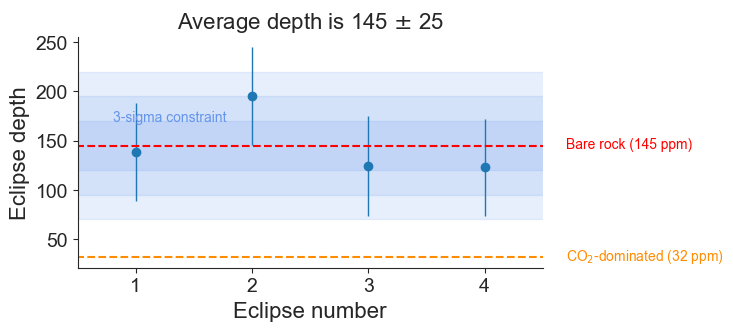

In [11]:
eclipse_number = np.arange(neclipses) + 1
depths = np.zeros(neclipses)
errors = np.zeros(neclipses)

for j in range(neclipses):

    _, data = make_eclipse(Nin, Nout, depth_rock, noise)
    depths[j], errors[j] = get_depth(data, Nin, Nout)

plt.figure( figsize=(6, 3) )

plt.errorbar( eclipse_number, depths, errors, fmt = 'o', elinewidth = 1)
average_eclipse = np.mean(depths)
average_eclipse_err = np.mean(errors) / np.sqrt( len(depths) )
plt.fill_between( [-0.5, len(depths)+2], average_eclipse - average_eclipse_err,
                                  average_eclipse + average_eclipse_err,
                                  alpha = 0.15, color = 'cornflowerblue')
plt.fill_between( [-0.5, len(depths)+2], average_eclipse - 2*average_eclipse_err,
                                  average_eclipse + 2*average_eclipse_err,
                                  alpha = 0.15, color = 'cornflowerblue')
plt.fill_between( [-0.5, len(depths)+2], average_eclipse - 3*average_eclipse_err,
                                  average_eclipse + 3*average_eclipse_err,
                                  alpha = 0.15, color = 'cornflowerblue')

plt.text(0.8, 170, '3-sigma constraint', color = 'cornflowerblue')

plt.plot( [-0.5, len(depths)+2], [depth_rock, depth_rock], 'r--' )
plt.text( np.max(eclipse_number)+0.7, depth_rock-3, 'Bare rock ({0:.0f} ppm)'.format(depth_rock), color = 'red' )
plt.plot( [-0.5, len(depths)+2], [depth_CO2, depth_CO2], '--', color = 'darkorange' )
plt.text( np.max(eclipse_number)+0.7, depth_CO2-3, 'CO$_2$-dominated ({0:.0f} ppm)'.format(depth_CO2), color = 'darkorange' )

plt.title(r'Average depth is {0:.0f} $\pm$ {1:.0f}'.format( average_eclipse, average_eclipse_err ),
          fontsize = 16)

plt.xlabel('Eclipse number', fontsize = 16)
plt.ylabel('Eclipse depth', fontsize = 16)
plt.xticks(eclipse_number, eclipse_number.astype('str'), fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlim(0.5,len(depths)+0.5)
plt.show()

But what if we tried to stop early? What if, as soon as we detect this is indeed a bare rock, we stop observing and reallocate the time to other targets? 

Let's assume we claim it's a bare rock as soon as at 3-sigma we can rule out the CO$_2$-dominated scenario at a given number of eclipses. First of all, at what number of eclipses did this happen on the experiment above? Let's check:

In [12]:
nsigma = 3

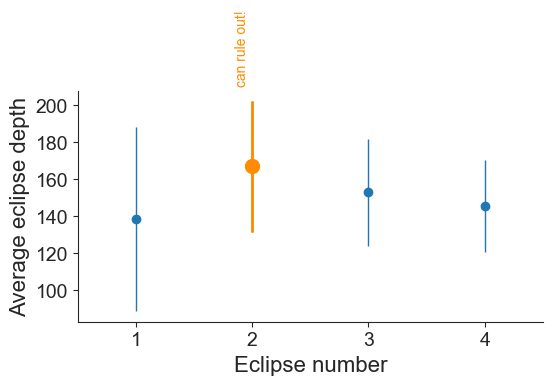

In [13]:
cummulative_eclipse_depth = np.zeros(neclipses)
cummulative_eclipse_depth_error = np.zeros(neclipses)


for j in range(neclipses):

    if j == 0:
        
        cummulative_eclipse_depth[j] = depths[j]
        cummulative_eclipse_depth_error[j] = errors[j]

    else:

        cummulative_eclipse_depth[j] = np.mean( depths[:j+1] )
        cummulative_eclipse_depth_error[j] = np.mean(errors[:j+1]) / np.sqrt( len(depths[:j+1]) )

plt.figure( figsize=(6, 3) )

plt.errorbar( eclipse_number, cummulative_eclipse_depth, cummulative_eclipse_depth_error, fmt = 'o', elinewidth = 1)
idx = np.where( (cummulative_eclipse_depth - depth_CO2) / cummulative_eclipse_depth_error > nsigma )[0]

plt.errorbar( eclipse_number[np.min(idx)], 
              cummulative_eclipse_depth[np.min(idx)], 
              cummulative_eclipse_depth_error[np.min(idx)], 
              fmt = 'o', color = 'darkorange', mec = 'darkorange', 
              ms = 10, elinewidth = 2)


plt.text( eclipse_number[np.min(idx)]-0.15, 
          cummulative_eclipse_depth[np.min(idx)] + cummulative_eclipse_depth_error[np.min(idx)] + 10, 
          'can rule out!', color = 'darkorange', rotation = 90 )

plt.xlabel('Eclipse number', fontsize = 16)
plt.ylabel('Average eclipse depth', fontsize = 16)
plt.xticks(eclipse_number, eclipse_number.astype('str'), fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlim(0.5,len(depths)+0.5)
plt.show()

In the example above, we could have claimed a bare rock (or, really, an "inconsistent with a CO$_2$-dominated scenario") at 2 eclipses. This is interesting (and a lucky alignment of our random seed) because, in a universe on which the Rocky Worlds DDT executed with the noise properties simulated above, those astronomers would have been able to claim a bare-rock at 3$\sigma$ after 2 eclipses using this criterion, which happens to be Checkpoint 1 for GJ 3929 b. However, note that the differentiation between a bare rock and a CO$_2$-dominated atmosphere is actually Checkpoint 2!

Of course, this is a single realization. Let's simulate many realizations and figure out the fraction of times we would have been able to claim such a detection at different number of eclipses if GJ 3929 b was, indeed, a bare rock:

In [14]:
nsim = 10000

In [15]:
# Save number of ocurrences for each eclipse number:
ocurrences = np.zeros(len(eclipse_number))

# Save the cummulative depths for each n-sigma detection:
cummulative_depths = {}
for j in range(neclipses):
    cummulative_depths[j] = np.array([])

# Run the simulation:
for i in range(nsim):

    # These will save the eclipse depth and error on a given eclipse:
    depths = np.zeros(neclipses)
    errors = np.zeros(neclipses)

    # This saves the cummulative eclipse depth up to eclipse j:
    cummulative_eclipse_depth = np.zeros(neclipses)
    cummulative_eclipse_depth_error = np.zeros(neclipses)

    # Run experiment for simulation i:
    for j in range(neclipses):

        # Observe the eclipse, get the depth:
        _, data = make_eclipse(Nin, Nout, depth_rock, noise)
        depths[j], errors[j] = get_depth(data, Nin, Nout)

        # Calculate the cummulative eclipse depth up to eclipse j:
        if j == 0:
            
            cummulative_eclipse_depth[j] = depths[j]
            cummulative_eclipse_depth_error[j] = errors[j]
    
        else:
    
            cummulative_eclipse_depth[j] = np.mean( depths[:j+1] )
            cummulative_eclipse_depth_error[j] = np.mean(errors[:j+1]) / np.sqrt( len(depths[:j+1]) )

    # Check after which eclipses we have a bare rock at n-sigma:
    idx = np.where( (cummulative_eclipse_depth - depth_CO2) / cummulative_eclipse_depth_error > nsigma )[0]
        
    # What is the minimum number of eclipses at which this happened? (sometimes it doesn't --- we don't count those):
    if len(idx) != 0:

        cummulative_depths[np.min(idx)] = np.append( cummulative_depths[np.min(idx)], cummulative_eclipse_depth[np.min(idx)])
        ocurrences[np.min(idx)] += 1

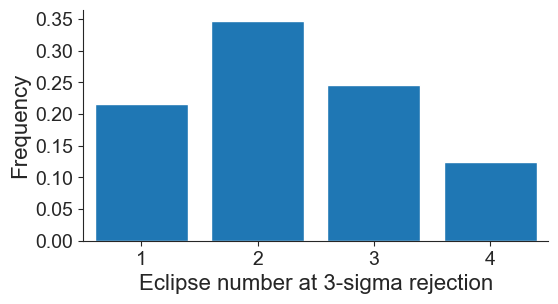

In [16]:
plt.figure(figsize=(6,3))

plt.bar( eclipse_number, ocurrences / nsim )

plt.xlabel('Eclipse number at {0:}-sigma rejection'.format(nsigma), fontsize = 16)
plt.ylabel('Frequency', fontsize = 16)
plt.xticks(eclipse_number, 
           eclipse_number.astype('str'), 
           fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlim(0.5,len(depths)+0.5)
plt.show()

So, about 35% of the time you would rule this out at 2 eclipses, and about 55% at 2 or 1 eclipses. Close but not quite 80% for 3, 2 or 1 eclipses. Note this is, in fact, a power analysis calculation for Checkpoint 2 --- and agrees with the selection of 4 eclipses as the one that offers above 80% statistical power.

One question this power analysis does not answer, however, is: how do we bias the eclipse depth we obtain if the object is truly a bare rock and we decide to stop observations at eclipse number $N$? We tracked the retrieved depths for each scenario in the simulation above --- let's see what we get:

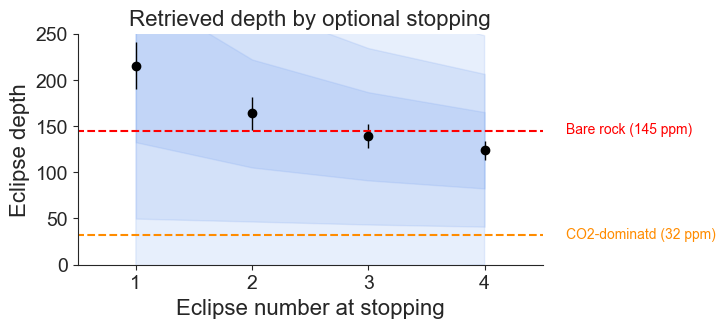

In [17]:
plt.figure( figsize=(6, 3) )

cdepths = np.zeros(len(eclipse_number))
cdepths_err = np.zeros(len(eclipse_number))
for i in range(len(eclipse_number)):

    cdepths[i] = np.mean(cummulative_depths[i])
    cdepths_err[i] = np.sqrt(np.var(cummulative_depths[i]))

plt.errorbar( eclipse_number, cdepths, cdepths_err, fmt = 'o', color = 'black', elinewidth = 1)

plt.plot( [-0.5, len(depths)+2], [depth_rock, depth_rock], 'r--' )
plt.text( np.max(eclipse_number)+0.7, depth_rock-3, 'Bare rock ({0:.0f} ppm)'.format(depth_rock), color = 'red' )
plt.plot( [-0.5, len(depths)+2], [depth_CO2, depth_CO2], '--', color = 'darkorange' )
plt.text( np.max(eclipse_number)+0.7, depth_CO2-3, 'CO2-dominatd ({0:.0f} ppm)'.format(depth_CO2), color = 'darkorange' )

# Compute the expected errorbar at each number of eclipse:
average_eclipse_errorbars = average_eclipse_err * np.sqrt( 11. / eclipse_number )
plt.fill_between( eclipse_number, cdepths - average_eclipse_errorbars,
                                  cdepths + average_eclipse_errorbars,
                                  alpha = 0.15, color = 'cornflowerblue')
plt.fill_between( eclipse_number, cdepths - 2*average_eclipse_errorbars,
                                  cdepths + 2*average_eclipse_errorbars,
                                  alpha = 0.15, color = 'cornflowerblue')
plt.fill_between( eclipse_number, cdepths - 3*average_eclipse_errorbars,
                                  cdepths + 3*average_eclipse_errorbars,
                                  alpha = 0.15, color = 'cornflowerblue')

plt.title(r'Retrieved depth by optional stopping', fontsize = 16)

plt.xlabel('Eclipse number at stopping', fontsize = 16)
plt.ylabel('Eclipse depth', fontsize = 16)
plt.xticks(eclipse_number, eclipse_number.astype('str'), fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlim(0.5,len(depths)+0.5)
plt.ylim(0, 250)
plt.show()

Let's plot the bias directly:

Eclipse stop | Bias - 1*sigma | MSE
1 | 20.273095128236704 |  7398.7519635382605
2 | -16.675467937548774 |  1586.381241946181
3 | -34.89680969085477 |  865.3613241025463
4 | -46.17405286771518 |  1072.7240629859884


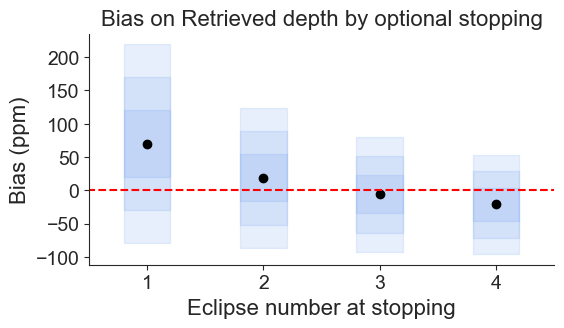

In [18]:
plt.figure( figsize=(6, 3) )

cdepths = np.zeros(len(eclipse_number))
cdepths_err = np.zeros(len(eclipse_number))
for i in range(len(eclipse_number)):

    cdepths[i] = np.mean(cummulative_depths[i])
    cdepths_err[i] = np.sqrt(np.var(cummulative_depths[i]))

per_eclipse_error = average_eclipse_err * np.sqrt( np.max(eclipse_number) )
print('Eclipse stop | Bias - 1*sigma | MSE')
for i in range( len(eclipse_number) ):

    en = eclipse_number[i]
    plt.fill_between( [en - 0.2, en + 0.2], 
                       cdepths[i] - depth_rock - per_eclipse_error / np.sqrt(en),
                       cdepths[i] - depth_rock + per_eclipse_error / np.sqrt(en),
                       alpha = 0.15, color = 'cornflowerblue')
    
    plt.fill_between( [en - 0.2, en + 0.2], 
                       cdepths[i] - depth_rock - 2. * per_eclipse_error / np.sqrt(en),
                       cdepths[i] - depth_rock + 2. * per_eclipse_error / np.sqrt(en),
                       alpha = 0.15, color = 'cornflowerblue')
    
    plt.fill_between( [en - 0.2, en + 0.2], 
                       cdepths[i] - depth_rock - 3. * per_eclipse_error / np.sqrt(en),
                       cdepths[i] - depth_rock + 3. * per_eclipse_error / np.sqrt(en),
                       alpha = 0.15, color = 'cornflowerblue')

    print(en,'|', 
          cdepths[i] - depth_rock - per_eclipse_error / np.sqrt(en), '| ', 
          (cdepths[i] - depth_rock)**2 + (per_eclipse_error / np.sqrt(en))**2)

plt.plot( eclipse_number, cdepths - depth_rock, 'o', color = 'black' )
plt.plot( [-0.5, len(depths)+2], [0, 0], 'r--' )

plt.title(r'Bias on Retrieved depth by optional stopping', fontsize = 16)

plt.xlabel('Eclipse number at stopping', fontsize = 16)
plt.ylabel('Bias (ppm)', fontsize = 16)
plt.xticks(eclipse_number, eclipse_number.astype('str'), fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlim(0.5,len(depths)+0.5)
plt.savefig('gj3929_bias.pdf')
plt.show()

So, turns out the observed depths are only significantly (as in, within the 1$\sigma$ errorbars) biased upwards if we stop before about 2 eclipses (i.e., bias is within 1-sigma of the real value). 

#### 2.3 What if the planet has a CO2-dominated atmosphere?

A good question from the experiment above is whether in the CO$_2$-dominated case we would ever reject the planet as a bare rock _in the case in which the real model is that of a planet with a CO$_2$-dominated atmosphere_. Does this ever happen? Let's repeat the simulations above, but assuming the CO2-dominated eclipse depth. Let's first do a single simulation to gain intuition:

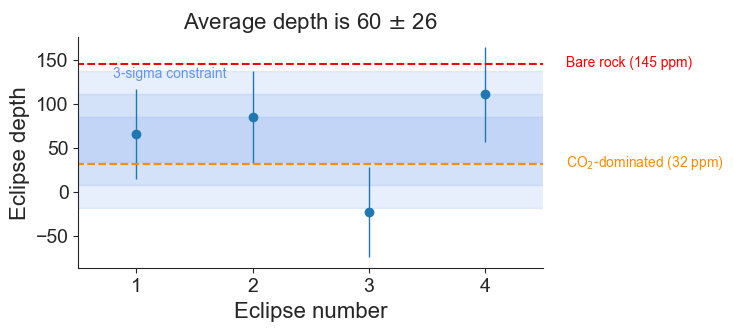

In [20]:
eclipse_number = np.arange(neclipses) + 1
depths = np.zeros(neclipses)
errors = np.zeros(neclipses)

for j in range(neclipses):

    _, data = make_eclipse(Nin, Nout, depth_CO2, noise)
    depths[j], errors[j] = get_depth(data, Nin, Nout)

plt.figure( figsize=(6, 3) )

plt.errorbar( eclipse_number, depths, errors, fmt = 'o', elinewidth = 1)
average_eclipse = np.mean(depths)
average_eclipse_err = np.mean(errors) / np.sqrt( len(depths) )
plt.fill_between( [-0.5, len(depths)+2], average_eclipse - average_eclipse_err,
                                  average_eclipse + average_eclipse_err,
                                  alpha = 0.15, color = 'cornflowerblue')
plt.fill_between( [-0.5, len(depths)+2], average_eclipse - 2*average_eclipse_err,
                                  average_eclipse + 2*average_eclipse_err,
                                  alpha = 0.15, color = 'cornflowerblue')
plt.fill_between( [-0.5, len(depths)+2], average_eclipse - 3*average_eclipse_err,
                                  average_eclipse + 3*average_eclipse_err,
                                  alpha = 0.15, color = 'cornflowerblue')

plt.text(0.8, 130, '3-sigma constraint', color = 'cornflowerblue')

plt.plot( [-0.5, len(depths)+2], [depth_rock, depth_rock], 'r--' )
plt.text( np.max(eclipse_number)+0.7, depth_rock-3, 'Bare rock ({0:.0f} ppm)'.format(depth_rock), color = 'red' )
plt.plot( [-0.5, len(depths)+2], [depth_CO2, depth_CO2], '--', color = 'darkorange' )
plt.text( np.max(eclipse_number)+0.7, depth_CO2-3, 'CO$_2$-dominated ({0:.0f} ppm)'.format(depth_CO2), color = 'darkorange' )

plt.title(r'Average depth is {0:.0f} $\pm$ {1:.0f}'.format( average_eclipse, average_eclipse_err ),
          fontsize = 16)

plt.xlabel('Eclipse number', fontsize = 16)
plt.ylabel('Eclipse depth', fontsize = 16)
plt.xticks(eclipse_number, eclipse_number.astype('str'), fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlim(0.5,len(depths)+0.5)
plt.show()

At first look it doesn't seem likely this would ever happen. Let's try 10,000 simulations, just as the bare rock case above:

In [21]:
# Save number of ocurrences for each eclipse number:
ocurrences = np.zeros(len(eclipse_number))

# Save the cummulative depths for each 4-sigma detection:
cummulative_depths = {}
for j in range(neclipses):
    cummulative_depths[j] = np.array([])

# Run the simulation:
for i in range(nsim):

    # These will save the eclipse depth and error on a given eclipse:
    depths = np.zeros(neclipses)
    errors = np.zeros(neclipses)

    # This saves the cummulative eclipse depth up to eclipse j:
    cummulative_eclipse_depth = np.zeros(neclipses)
    cummulative_eclipse_depth_error = np.zeros(neclipses)

    # Run experiment for simulation i:
    for j in range(neclipses):

        # Observe the eclipse, get the depth:
        _, data = make_eclipse(Nin, Nout, depth_CO2, noise)
        depths[j], errors[j] = get_depth(data, Nin, Nout)

        # Calculate the cummulative eclipse depth up to eclipse j:
        if j == 0:
            
            cummulative_eclipse_depth[j] = depths[j]
            cummulative_eclipse_depth_error[j] = errors[j]
    
        else:
    
            cummulative_eclipse_depth[j] = np.mean( depths[:j+1] )
            cummulative_eclipse_depth_error[j] = np.mean(errors[:j+1]) / np.sqrt( len(depths[:j+1]) )

    # Check after which eclipses we have a bare rock at n-sigma:
    idx = np.where( (cummulative_eclipse_depth - depth_CO2) / cummulative_eclipse_depth_error > nsigma )[0]
    
    # What is the minimum number of eclipses at which this happened? (sometimes it doesn't --- we don't count those):
    if len(idx) != 0:

        cummulative_depths[np.min(idx)] = np.append( cummulative_depths[np.min(idx)], cummulative_eclipse_depth[np.min(idx)])
        ocurrences[np.min(idx)] += 1

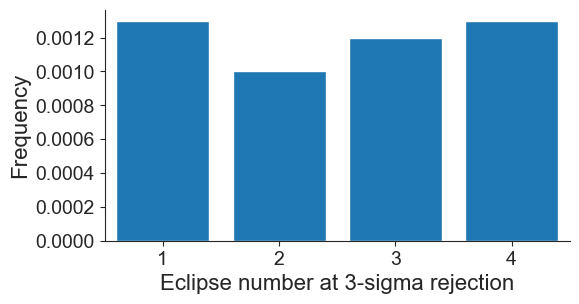

In [22]:
plt.figure(figsize=(6,3))

plt.bar( eclipse_number, ocurrences / nsim )

plt.xlabel('Eclipse number at {0:}-sigma rejection'.format(nsigma), fontsize = 16)
plt.ylabel('Frequency', fontsize = 16)
plt.xticks(eclipse_number, 
           eclipse_number.astype('str'), 
           fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlim(0.5,len(depths)+0.5)
plt.show()

Indeed, it almost never happens! In much less than 1% of the simulations. So this one is good in terms of falsely rejecting a very interesting case.

### 2.2 The case of LHS 1140 b

Let's repeat the calculation for LHS 1140 b:

In [23]:
target = 'LHS 1140 b'
depth_rock = CIT_calculations[target]['bare rock depth']                           # depth of the bare rock-scenario, in ppm
depth_CO2 = CIT_calculations[target]['CO2 depth']                                  # depth of the CO2-dominated scenario, in ppm
tintegration = CIT_calculations[target]['time per integration']                    # secs from SUB128 subarray
tdur = CIT_calculations[target]['eclipse duration'] * 3600                         # (hours/eclipse ) x (secs / hour)
Ntot = int( CIT_calculations[target]['observing time'] * 3600. / tintegration )
Nin = int( tdur / tintegration )
Nout = Ntot-Nin
noise = CIT_calculations[target]['precision per integration'] * 1.25               # Noise x Rocky Worlds DDT factor
neclipses = 10                                                                     # number of maximum eclipses to observe

Let's build intuition in terms of getting a single realization of these eclipses:

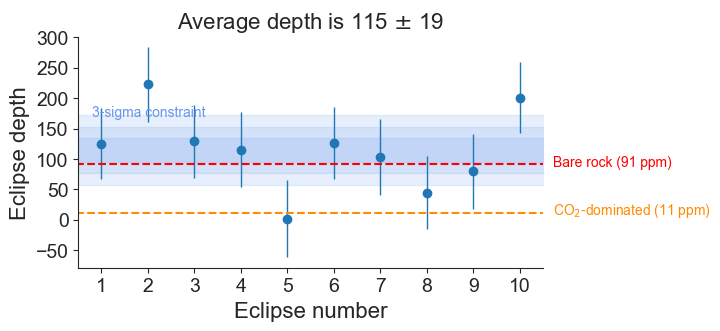

In [24]:
eclipse_number = np.arange(neclipses) + 1
depths = np.zeros(neclipses)
errors = np.zeros(neclipses)

for j in range(neclipses):

    _, data = make_eclipse(Nin, Nout, depth_rock, noise)
    depths[j], errors[j] = get_depth(data, Nin, Nout)

plt.figure( figsize=(6, 3) )

plt.errorbar( eclipse_number, depths, errors, fmt = 'o', elinewidth = 1)
average_eclipse = np.mean(depths)
average_eclipse_err = np.mean(errors) / np.sqrt( len(depths) )
plt.fill_between( [-0.5, len(depths)+2], average_eclipse - average_eclipse_err,
                                  average_eclipse + average_eclipse_err,
                                  alpha = 0.15, color = 'cornflowerblue')
plt.fill_between( [-0.5, len(depths)+2], average_eclipse - 2*average_eclipse_err,
                                  average_eclipse + 2*average_eclipse_err,
                                  alpha = 0.15, color = 'cornflowerblue')
plt.fill_between( [-0.5, len(depths)+2], average_eclipse - 3*average_eclipse_err,
                                  average_eclipse + 3*average_eclipse_err,
                                  alpha = 0.15, color = 'cornflowerblue')

plt.text(0.8, 170, '3-sigma constraint', color = 'cornflowerblue')

plt.plot( [-0.5, len(depths)+2], [depth_rock, depth_rock], 'r--' )
plt.text( np.max(eclipse_number)+0.7, depth_rock-3, 'Bare rock ({0:.0f} ppm)'.format(depth_rock), color = 'red' )
plt.plot( [-0.5, len(depths)+2], [depth_CO2, depth_CO2], '--', color = 'darkorange' )
plt.text( np.max(eclipse_number)+0.7, depth_CO2-3, 'CO$_2$-dominated ({0:.0f} ppm)'.format(depth_CO2), color = 'darkorange' )

plt.title(r'Average depth is {0:.0f} $\pm$ {1:.0f}'.format( average_eclipse, average_eclipse_err ),
          fontsize = 16)

plt.xlabel('Eclipse number', fontsize = 16)
plt.ylabel('Eclipse depth', fontsize = 16)
plt.xticks(eclipse_number, eclipse_number.astype('str'), fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlim(0.5,len(depths)+0.5)
plt.show()

In [25]:
# Save number of ocurrences for each eclipse number:
ocurrences = np.zeros(len(eclipse_number))

# Save the cummulative depths for each n-sigma detection:
cummulative_depths = {}
for j in range(neclipses):
    cummulative_depths[j] = np.array([])

# Run the simulation:
for i in range(nsim):

    # These will save the eclipse depth and error on a given eclipse:
    depths = np.zeros(neclipses)
    errors = np.zeros(neclipses)

    # This saves the cummulative eclipse depth up to eclipse j:
    cummulative_eclipse_depth = np.zeros(neclipses)
    cummulative_eclipse_depth_error = np.zeros(neclipses)

    # Run experiment for simulation i:
    for j in range(neclipses):

        # Observe the eclipse, get the depth:
        _, data = make_eclipse(Nin, Nout, depth_rock, noise)
        depths[j], errors[j] = get_depth(data, Nin, Nout)

        # Calculate the cummulative eclipse depth up to eclipse j:
        if j == 0:
            
            cummulative_eclipse_depth[j] = depths[j]
            cummulative_eclipse_depth_error[j] = errors[j]
    
        else:
    
            cummulative_eclipse_depth[j] = np.mean( depths[:j+1] )
            cummulative_eclipse_depth_error[j] = np.mean(errors[:j+1]) / np.sqrt( len(depths[:j+1]) )

    # Check after which eclipses we have a bare rock at n-sigma:
    idx = np.where( (cummulative_eclipse_depth - depth_CO2) / cummulative_eclipse_depth_error > nsigma )[0]
        
    # What is the minimum number of eclipses at which this happened? (sometimes it doesn't --- we don't count those):
    if len(idx) != 0:

        cummulative_depths[np.min(idx)] = np.append( cummulative_depths[np.min(idx)], cummulative_eclipse_depth[np.min(idx)])
        ocurrences[np.min(idx)] += 1

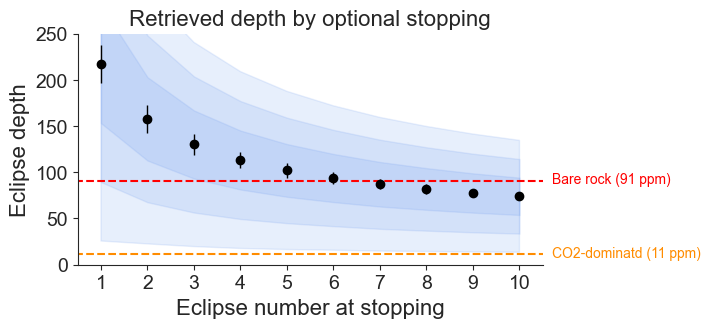

In [26]:
plt.figure( figsize=(6, 3) )

cdepths = np.zeros(len(eclipse_number))
cdepths_err = np.zeros(len(eclipse_number))
for i in range(len(eclipse_number)):

    cdepths[i] = np.mean(cummulative_depths[i])
    cdepths_err[i] = np.sqrt(np.var(cummulative_depths[i]))

plt.errorbar( eclipse_number, cdepths, cdepths_err, fmt = 'o', color = 'black', elinewidth = 1)

plt.plot( [-0.5, len(depths)+2], [depth_rock, depth_rock], 'r--' )
plt.text( np.max(eclipse_number)+0.7, depth_rock-3, 'Bare rock ({0:.0f} ppm)'.format(depth_rock), color = 'red' )
plt.plot( [-0.5, len(depths)+2], [depth_CO2, depth_CO2], '--', color = 'darkorange' )
plt.text( np.max(eclipse_number)+0.7, depth_CO2-3, 'CO2-dominatd ({0:.0f} ppm)'.format(depth_CO2), color = 'darkorange' )

# Compute the expected errorbar at each number of eclipse:
average_eclipse_errorbars = average_eclipse_err * np.sqrt( 11. / eclipse_number )
plt.fill_between( eclipse_number, cdepths - average_eclipse_errorbars,
                                  cdepths + average_eclipse_errorbars,
                                  alpha = 0.15, color = 'cornflowerblue')
plt.fill_between( eclipse_number, cdepths - 2*average_eclipse_errorbars,
                                  cdepths + 2*average_eclipse_errorbars,
                                  alpha = 0.15, color = 'cornflowerblue')
plt.fill_between( eclipse_number, cdepths - 3*average_eclipse_errorbars,
                                  cdepths + 3*average_eclipse_errorbars,
                                  alpha = 0.15, color = 'cornflowerblue')

plt.title(r'Retrieved depth by optional stopping', fontsize = 16)

plt.xlabel('Eclipse number at stopping', fontsize = 16)
plt.ylabel('Eclipse depth', fontsize = 16)
plt.xticks(eclipse_number, eclipse_number.astype('str'), fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlim(0.5,len(depths)+0.5)
plt.ylim(0, 250)
plt.show()

Eclipse stop | Bias - 1*sigma | MSE
1 | 65.11330866610069 |  19559.796411345877
2 | 23.741411927480186 |  6305.418554505488
3 | 3.9094720539305285 |  2756.239820242162
4 | -8.228797820958437 |  1416.9886695480184
5 | -16.26676713201873 |  859.4791325386261
6 | -22.105166755489886 |  624.0268433769685
7 | -27.01163281570392 |  544.6887147023324
8 | -30.628594928745486 |  545.6941501978586
9 | -33.76500564690097 |  593.0517383520299
10 | -36.29155180518316 |  660.9079810489521


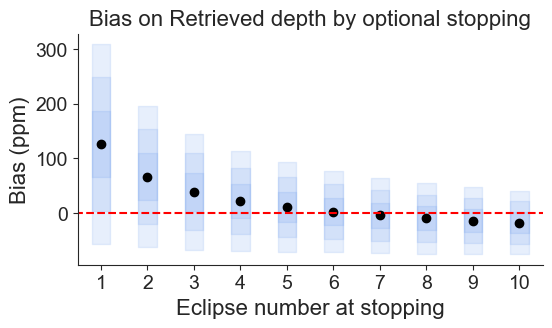

In [27]:
plt.figure( figsize=(6, 3) )

cdepths = np.zeros(len(eclipse_number))
cdepths_err = np.zeros(len(eclipse_number))
for i in range(len(eclipse_number)):

    cdepths[i] = np.mean(cummulative_depths[i])
    cdepths_err[i] = np.sqrt(np.var(cummulative_depths[i]))

per_eclipse_error = average_eclipse_err * np.sqrt( np.max(eclipse_number) )
print('Eclipse stop | Bias - 1*sigma | MSE')
for i in range( len(eclipse_number) ):

    en = eclipse_number[i]
    plt.fill_between( [en - 0.2, en + 0.2], 
                       cdepths[i] - depth_rock - per_eclipse_error / np.sqrt(en),
                       cdepths[i] - depth_rock + per_eclipse_error / np.sqrt(en),
                       alpha = 0.15, color = 'cornflowerblue')
    
    plt.fill_between( [en - 0.2, en + 0.2], 
                       cdepths[i] - depth_rock - 2. * per_eclipse_error / np.sqrt(en),
                       cdepths[i] - depth_rock + 2. * per_eclipse_error / np.sqrt(en),
                       alpha = 0.15, color = 'cornflowerblue')
    
    plt.fill_between( [en - 0.2, en + 0.2], 
                       cdepths[i] - depth_rock - 3. * per_eclipse_error / np.sqrt(en),
                       cdepths[i] - depth_rock + 3. * per_eclipse_error / np.sqrt(en),
                       alpha = 0.15, color = 'cornflowerblue')

    print(en,'|', 
          cdepths[i] - depth_rock - per_eclipse_error / np.sqrt(en), '| ', 
          (cdepths[i] - depth_rock)**2 + (per_eclipse_error / np.sqrt(en))**2)

plt.plot( eclipse_number, cdepths - depth_rock, 'o', color = 'black' )
plt.plot( [-0.5, len(depths)+2], [0, 0], 'r--' )

plt.title(r'Bias on Retrieved depth by optional stopping', fontsize = 16)

plt.xlabel('Eclipse number at stopping', fontsize = 16)
plt.ylabel('Bias (ppm)', fontsize = 16)
plt.xticks(eclipse_number, eclipse_number.astype('str'), fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlim(0.5,len(depths)+0.5)
plt.savefig('lhs1140b_bias.pdf')
plt.show()

In this case, it seems the bias is significant up to the ~4th eclipse.

***

<table style="width:100%; border:0;">
<tr>
<td style="text-align:left; vertical-align:middle;">
<a href="#top">Top of Page</a>
</td>

<td style="text-align:right; vertical-align:middle;">
<img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/7f391657bc2bf47a784400d65d2882703787416d/stsci_logo2.png"
     alt="Space Telescope Logo"
     width="80px"/>
</td>
</tr>
</table>